# 🧠 Neuro-Symbolic LLM Reliability Engine
**Full Pipeline — Data Preprocessing → ML Training → Symbolic Reasoning → FastAPI Backend**

| | |
|---|---|
| **Student** | Kommera Shanmukhi — 23STUCHH011304 |
| **University** | IFHE University, Faculty of Science & Technology |
| **Dataset** | FEVER v1.0 (~185,455 annotated claims from Wikipedia) |
| **Model** | RoBERTa-base fine-tuned for 3-class Fact Verification |
| **Backend** | FastAPI|

>

---
### 📋 End-to-End Pipeline
```
FEVER Dataset (185K claims)
        │
        ▼
[STEP 1] Install & Imports
        │
        ▼
[STEP 2] Data Collection & Exploration
        │
        ▼
[STEP 3] Data Preprocessing & Tokenization
        │
        ▼
[STEP 4] Knowledge Base Construction (JSON + RDF)
        │
        ▼
[STEP 5] Claim Extraction Module (spaCy NER + Dep. Parsing)
        │
        ▼
[STEP 6] Symbolic Representation Layer
        │
        ▼
[STEP 7] RoBERTa Fine-tuning on FEVER (145K training claims)
        │
        ▼
[STEP 8] Rule-Based Verification Engine
        │
        ▼
[STEP 9] Reliability Scoring (weighted 0–1 formula)
        │
        ▼
[STEP 10] Evaluation & Confusion Matrix
        │
        ▼
[STEP 11] FastAPI Backend
```


## ⚙️ Step 1 — Install Dependencies & Imports

In [ ]:


!pip uninstall -y transformers peft 2>/dev/null


!pip install -q transformers==4.38.2
!pip install -q peft==0.9.0


!pip install -q datasets==2.18.0 accelerate evaluate
!pip install -q torch torchvision torchaudio
!pip install -q fastapi uvicorn pydantic nest_asyncio
!pip install -q nltk rdflib scikit-learn pandas numpy tqdm matplotlib seaborn
!pip install -q rouge_score


!pip install -q spacy
!pip install -q https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.7.1/en_core_web_sm-3.7.1-py3-none-any.whl



import transformers
print(f"transformers version: {transformers.__version__}")
print("✅ All packages installed successfully!")

Found existing installation: transformers 4.38.2
Uninstalling transformers-4.38.2:
  Successfully uninstalled transformers-4.38.2
Found existing installation: peft 0.18.1
Uninstalling peft-0.18.1:
  Successfully uninstalled peft-0.18.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 510.5/510.5 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.9/170.9 kB 20.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<

In [ ]:
import os, json, re, warnings, random
from pathlib import Path
from collections import defaultdict, Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset, DataLoader

import spacy
import nltk
from nltk.tokenize import sent_tokenize

from datasets import load_dataset
from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer, EarlyStoppingCallback
)
import evaluate

from rdflib import Graph, URIRef, Literal, Namespace
from rdflib.namespace import RDF

warnings.filterwarnings("ignore")
nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🖥️  Device: {DEVICE}")
print(f"🐍  PyTorch: {torch.__version__}")

nlp = spacy.load("en_core_web_sm")
print("✅ spaCy en_core_web_sm loaded")

# Label mappings
LABEL2ID = {"SUPPORTS": 0, "REFUTES": 1, "NOT ENOUGH INFO": 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
MODEL_NAME = "roberta-base"
MAX_LEN    = 256


🖥️  Device: cuda
🐍  PyTorch: 2.10.0+cu128
✅ spaCy en_core_web_sm loaded


## 📦 Step 2 — Data Collection (FEVER v1.0 Dataset)

**FEVER** (Fact Extraction and VERification) is one of the largest fact-checking benchmarks:

| Split | Size | Description |
|-------|------|-------------|
| Train | 145,449 | Claims with Wikipedia evidence labels |
| Validation | 19,998 | Dev set for hyperparameter tuning |

**Label distribution (approximate):**
- `SUPPORTS` — ~36%  
- `REFUTES` — ~36%  
- `NOT ENOUGH INFO` — ~28%


In [ ]:
# Downloading FEVER dataset from HuggingFace (≈185K claims total)
print("📥 Downloading FEVER v1.0 dataset...")
fever = load_dataset("fever", "v1.0")
print(fever)

print("\n📋 Sample examples from training set:")
for i in range(3):
    ex = fever["train"][i]
    print(f"  [{i}] Label: {ex['label']:20s} | Claim: {ex['claim'][:75]}...")


📥 Downloading FEVER v1.0 dataset...
DatasetDict({
    train: Dataset({
        features: ['id', 'label', 'claim', 'evidence_annotation_id', 'evidence_id', 'evidence_wiki_url', 'evidence_sentence_id'],
        num_rows: 311431
    })
    labelled_dev: Dataset({
        features: ['id', 'label', 'claim', 'evidence_annotation_id', 'evidence_id', 'evidence_wiki_url', 'evidence_sentence_id'],
        num_rows: 37566
    })
    unlabelled_dev: Dataset({
        features: ['id', 'label', 'claim', 'evidence_annotation_id', 'evidence_id', 'evidence_wiki_url', 'evidence_sentence_id'],
        num_rows: 19998
    })
    unlabelled_test: Dataset({
        features: ['id', 'label', 'claim', 'evidence_annotation_id', 'evidence_id', 'evidence_wiki_url', 'evidence_sentence_id'],
        num_rows: 19998
    })
    paper_dev: Dataset({
        features: ['id', 'label', 'claim', 'evidence_annotation_id', 'evidence_id', 'evidence_wiki_url', 'evidence_sentence_id'],
        num_rows: 18999
    })
    paper

Training set: 311,431 examples
Validation:   37,566 examples

Label distribution (train):
label
SUPPORTS           193756
REFUTES             70066
NOT ENOUGH INFO     47609
Name: count, dtype: int64


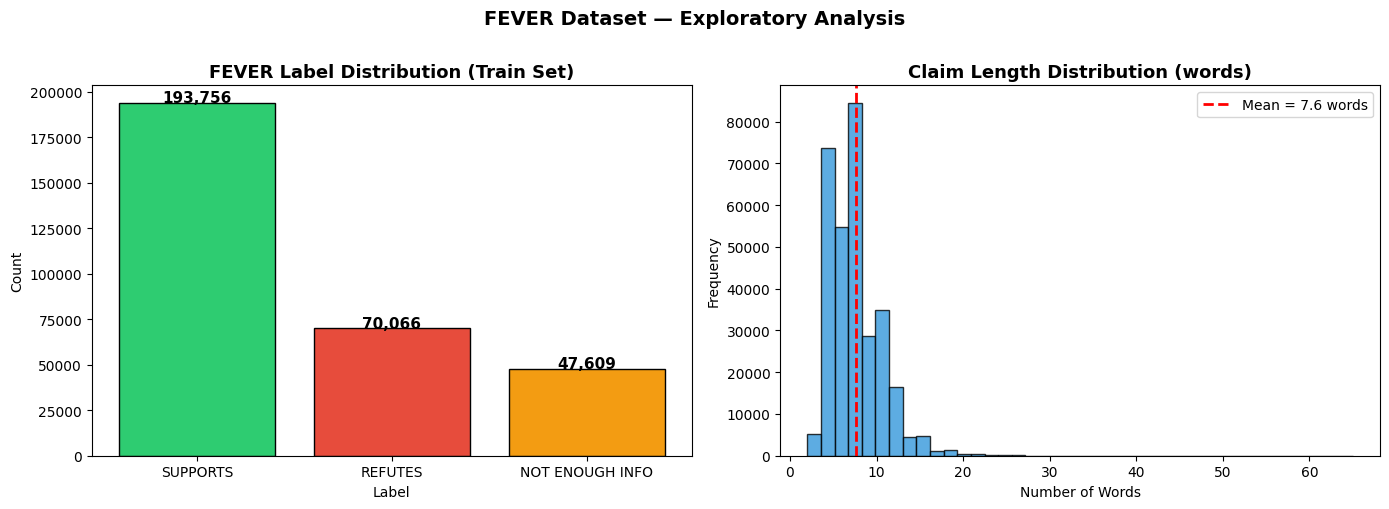


Mean claim length: 7.6 words


In [ ]:
# Exploratory Data Analysis
train_df = pd.DataFrame(fever["train"])
val_df   = pd.DataFrame(fever["labelled_dev"])

print(f"Training set: {len(train_df):,} examples")
print(f"Validation:   {len(val_df):,} examples")
print("\nLabel distribution (train):")
print(train_df["label"].value_counts())

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Label distribution
label_counts = train_df["label"].value_counts()
colors = ["#2ecc71", "#e74c3c", "#f39c12"]
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor="black")
axes[0].set_title("FEVER Label Distribution (Train Set)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Label"); axes[0].set_ylabel("Count")
for bar, val in zip(axes[0].patches, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 300,
                 f"{val:,}", ha="center", fontsize=11, fontweight="bold")

# Claim length distribution
train_df["claim_len"] = train_df["claim"].str.split().str.len()
axes[1].hist(train_df["claim_len"], bins=40, color="#3498db", edgecolor="black", alpha=0.8)
axes[1].set_title("Claim Length Distribution (words)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Number of Words"); axes[1].set_ylabel("Frequency")
mean_len = train_df["claim_len"].mean()
axes[1].axvline(mean_len, color="red", linestyle="--", linewidth=2,
                label=f"Mean = {mean_len:.1f} words")
axes[1].legend()

plt.suptitle("FEVER Dataset — Exploratory Analysis", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("data_distribution.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"\nMean claim length: {mean_len:.1f} words")


## 🧹 Step 3 — Data Preprocessing & Tokenization

Steps:
1. **Text normalization** : strip whitespace, remove control characters
2. **Label encoding** : SUPPORTS→0, REFUTES→1, NOT ENOUGH INFO→2  
3. **Evidence extraction** : flatten nested evidence lists
4. **RoBERTa tokenization** : claim + evidence pairs, max 256 tokens


In [ ]:
def normalize_text(text: str) -> str:
    if not text:
        return ""
    text = text.strip()
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"[\x00-\x1f\x7f]", "", text)
    return text

def preprocess_example(example: dict) -> dict:
    claim = normalize_text(example["claim"])

    # Flatten nested evidence list
    evidence_text = ""
    if example.get("evidence") and isinstance(example["evidence"], list):
        ev_flat = []
        for ev_group in example["evidence"]:
            if isinstance(ev_group, list):
                for ev in ev_group:
                    if isinstance(ev, list) and len(ev) >= 3 and ev[2]:
                        ev_flat.append(str(ev[2])[:200])
        evidence_text = " | ".join(ev_flat[:3])

    return {
        "claim":     claim,
        "evidence":  evidence_text,
        "label":     LABEL2ID.get(example["label"], 2),
        "label_str": example["label"]
    }

print("Preprocessing training data...")
processed_train = [preprocess_example(ex) for ex in tqdm(fever["train"],      desc="Train")]
processed_val   = [preprocess_example(ex) for ex in tqdm(fever["labelled_dev"],desc="Val  ")]

train_pdf = pd.DataFrame(processed_train)
val_pdf   = pd.DataFrame(processed_val)

print(f"\nTrain: {len(train_pdf):,} | Val: {len(val_pdf):,}")
print("Label distribution (encoded):")
print(train_pdf["label"].map(ID2LABEL).value_counts())

from transformers import AutoTokenizer

MODEL_NAME = "roberta-base"
MAX_LEN    = 256

print(f"\nLoading tokenizer: {MODEL_NAME}...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"✅ Tokenizer loaded — vocab size: {tokenizer.vocab_size:,}")


Preprocessing training data...


Train:   0%|          | 0/311431 [00:00<?, ?it/s]

Val  :   0%|          | 0/37566 [00:00<?, ?it/s]


Train: 311,431 | Val: 37,566
Label distribution (encoded):
label
SUPPORTS           193756
REFUTES             70066
NOT ENOUGH INFO     47609
Name: count, dtype: int64

Loading tokenizer: roberta-base...
✅ Tokenizer loaded — vocab size: 50,265


In [ ]:

from datasets import Dataset as HFDataset
import gc
gc.collect()
torch.cuda.empty_cache()


TRAIN_SIZE = 30000
VAL_SIZE   = 5000

# Stratified sampling
from collections import defaultdict
import random

def stratified_sample(data, n):
    by_label = defaultdict(list)
    for ex in data:
        by_label[ex["label"]].append(ex)
    per_class = n // 3
    sampled = []
    for label_examples in by_label.values():
        sampled.extend(random.sample(label_examples, min(per_class, len(label_examples))))
    random.shuffle(sampled)
    return sampled[:n]

random.seed(42)
train_sample = stratified_sample(processed_train, TRAIN_SIZE)
val_sample   = stratified_sample(processed_val,   VAL_SIZE)

print(f"Train sample: {len(train_sample):,} | Val sample: {len(val_sample):,}")

#  Tokenize in chunks to avoid memory spikes
def make_hf_dataset(data_list, tok, max_length=MAX_LEN):
    CHUNK = 2000
    all_input_ids, all_attention_masks, all_labels = [], [], []

    for i in tqdm(range(0, len(data_list), CHUNK), desc="Tokenizing"):
        chunk     = data_list[i:i+CHUNK]
        claims    = [ex["claim"]    for ex in chunk]
        evidences = [ex["evidence"] if ex.get("evidence") else "" for ex in chunk]
        labels    = [ex["label"]    for ex in chunk]

        enc = tok(claims, evidences, max_length=max_length,
                  padding="max_length", truncation=True)

        all_input_ids.extend(enc["input_ids"])
        all_attention_masks.extend(enc["attention_mask"])
        all_labels.extend(labels)


        del enc, claims, evidences, labels
        gc.collect()

    dataset = HFDataset.from_dict({
        "input_ids":      all_input_ids,
        "attention_mask": all_attention_masks,
        "labels":         all_labels,
    })
    dataset.set_format("torch")
    return dataset

print("Tokenizing train...")
hf_train = make_hf_dataset(train_sample, tokenizer)
gc.collect()

print("Tokenizing val...")
hf_val = make_hf_dataset(val_sample, tokenizer)
gc.collect()

sample = hf_train[0]
print(f"\nSample input_ids shape: {sample['input_ids'].shape}")
print(f"HF Train: {len(hf_train):,} | HF Val: {len(hf_val):,}")
print("✅ Tokenization complete!")


Train sample: 30,000 | Val sample: 4,998
Tokenizing train...


Tokenizing:   0%|          | 0/15 [00:00<?, ?it/s]

Tokenizing val...


Tokenizing:   0%|          | 0/3 [00:00<?, ?it/s]


Sample input_ids shape: torch.Size([256])
HF Train: 30,000 | HF Val: 4,998
✅ Tokenization complete!


## 🗄️ Step 4 — Knowledge Base Construction

Two-layer Knowledge Base:
1. **JSON store** — fast `O(1)` lookup by predicate key
2. **RDF Graph** — semantic triple store with SPARQL query support

Sources:
- Hand-curated domain facts (geography, science, history)
- High-confidence SUPPORTED claims from FEVER training set (~5,000 entries)


In [ ]:
#  Seed with curated facts
SEED_FACTS = {
    "capital_of": [
        ("france","paris"),("germany","berlin"),("japan","tokyo"),("india","new delhi"),
        ("usa","washington dc"),("uk","london"),("china","beijing"),("russia","moscow"),
        ("brazil","brasilia"),("australia","canberra"),("canada","ottawa"),("italy","rome"),
        ("spain","madrid"),("egypt","cairo"),("mexico","mexico city"),("argentina","buenos aires"),
        ("south africa","pretoria"),("nigeria","abuja"),("kenya","nairobi"),
    ],
    "located_in": [
        ("eiffel tower","paris"),("big ben","london"),("colosseum","rome"),
        ("statue of liberty","new york"),("taj mahal","agra"),
        ("amazon river","south america"),("mount everest","himalayas"),
        ("sahara desert","africa"),("nile river","africa"),("great wall","china"),
    ],
    "is_a": [
        ("dog","mammal"),("eagle","bird"),("python","programming language"),
        ("water","compound"),("gold","element"),("earth","planet"),
        ("shakespeare","playwright"),("einstein","physicist"),
        ("beethoven","composer"),("darwin","scientist"),("newton","physicist"),
        ("sun","star"),("moon","natural satellite"),
    ],
    "created_by": [
        ("hamlet","shakespeare"),("theory of relativity","einstein"),
        ("mona lisa","da vinci"),("apple company","steve jobs"),
        ("microsoft","bill gates"),("facebook","mark zuckerberg"),
        ("linux","linus torvalds"),("python language","guido van rossum"),
        ("windows","microsoft"),("google","larry page and sergey brin"),
    ],
    "born_in": [
        ("shakespeare","england"),("einstein","germany"),("newton","england"),
        ("marie curie","poland"),("gandhi","india"),("tesla","serbia"),
        ("napoleon","france"),("mozart","austria"),("darwin","england"),
    ],
}

json_kb = {}
for relation, pairs in SEED_FACTS.items():
    for subj, obj in pairs:
        key = f"{relation}({subj},{obj})"
        json_kb[key] = {"verified":True,"relation":relation,
                        "subject":subj,"object":obj,"source":"curated"}

print(f"Seed KB size: {len(json_kb)} entries")

# Augment from FEVER SUPPORTS
print("Augmenting KB from FEVER SUPPORTED claims...")
supported = train_pdf[train_pdf["label_str"] == "SUPPORTS"].head(5000)

AUGMENT_PATTERNS = [
    (r"(.+?) is (?:located|situated|found) in (.+)", "located_in"),
    (r"(.+?) is the capital of (.+)",                "capital_of"),
    (r"(.+?) was born in (.+)",                      "born_in"),
    (r"(.+?) is a(?:n)? (.+)",                       "is_a"),
    (r"(.+?) was (?:created|invented|written) by (.+)","created_by"),
]

added = 0
for _, row in tqdm(supported.iterrows(), total=len(supported), desc="KB augment"):
    cl = row["claim"].lower()
    for pat, rel in AUGMENT_PATTERNS:
        m = re.search(pat, cl)
        if m:
            g = m.groups()
            if rel == "capital_of":
                s, o = g[1].strip()[:50], g[0].strip()[:50]
            else:
                s, o = g[0].strip()[:50], g[-1].strip()[:50]
            key = f"{rel}({s},{o})"
            if key not in json_kb and len(s)>=3 and len(o)>=3:
                json_kb[key] = {"verified":True,"relation":rel,"subject":s,
                                "object":o,"source":"fever_supported"}
                added += 1

Path("knowledge_base.json").write_text(json.dumps(json_kb, indent=2))
print(f"\nFinal KB size: {len(json_kb):,} entries  (+{added} from FEVER)")
print("Saved → knowledge_base.json")


Seed KB size: 61 entries
Augmenting KB from FEVER SUPPORTED claims...


KB augment:   0%|          | 0/5000 [00:00<?, ?it/s]


Final KB size: 447 entries  (+386 from FEVER)
Saved → knowledge_base.json


In [ ]:
#  RDF Graph (semantic triple store)
NS = Namespace("http://neuro-symbolic-kb.org/")
g  = Graph()
g.bind("ns", NS)

for key, val in list(json_kb.items())[:3000]:
    s = URIRef(NS + val["subject"].replace(" ", "_"))
    o = URIRef(NS + val["object"].replace(" ", "_"))
    r = URIRef(NS + val["relation"])
    g.add((s, r, o))
    g.add((s, RDF.type, NS.Entity))

print(f"RDF Graph: {len(g)} triples")

# SPARQL query example
sparql_q = "SELECT ?s ?o WHERE { ?s <http://neuro-symbolic-kb.org/capital_of> ?o . } LIMIT 6"
print("\nSPARQL — capital_of relations:")
for row in g.query(sparql_q):
    subj_name = str(row[0]).split("/")[-1].replace("_", " ")
    obj_name  = str(row[1]).split("/")[-1].replace("_", " ")
    print(f"  {subj_name}  →  capital_of  →  {obj_name}")


RDF Graph: 820 triples

SPARQL — capital_of relations:
  france  →  capital_of  →  paris
  germany  →  capital_of  →  berlin
  germany.  →  capital_of  →  berlin
  japan  →  capital_of  →  tokyo
  india  →  capital_of  →  new delhi
  usa  →  capital_of  →  washington dc


## 🔍 Step 5 — Claim Extraction Module

Extracts **(Subject, Relation, Object)** triples from text using two strategies:

**Strategy A — Pattern matching:**  
Regex patterns for common fact expression forms (capital, location, birth, creation...)

**Strategy B — Dependency parsing:**  
spaCy ROOT verb analysis with `nsubj` / `dobj` dependency arcs  

Example:  
`"The Eiffel Tower is located in Paris"` → `(eiffel tower, located_in, paris)`


In [ ]:
class ClaimExtractor:
    PATTERNS = [
        (r"(.+?)\s+is\s+the\s+capital\s+of\s+(.+)",          "capital_of"),
        (r"(.+?)\s+is\s+(?:located|situated|found)\s+in\s+(.+)", "located_in"),
        (r"(.+?)\s+was\s+born\s+in\s+(.+)",                   "born_in"),
        (r"(.+?)\s+was\s+(?:created|invented|founded)\s+by\s+(.+)", "created_by"),
        (r"(.+?)\s+is\s+an?\s+(.+)",                          "is_a"),
        (r"(.+?)\s+(?:won|received)\s+the\s+(.+)",            "received_award"),
        (r"(.+?)\s+directed\s+(.+)",                          "directed_by"),
        (r"(.+?)\s+is\s+part\s+of\s+(.+)",                    "part_of"),
        (r"(.+?)\s+wrote\s+(.+)",                             "created_by"),
    ]

    def __init__(self, nlp_model):
        self.nlp = nlp_model

    def extract(self, text: str) -> list:
        triples, seen = [], set()
        clean = normalize_text(text)
        doc   = self.nlp(clean)

        # Pattern-based
        for sent in doc.sents:
            s = sent.text.lower()
            for pat, rel in self.PATTERNS:
                m = re.search(pat, s)
                if m:
                    gg = m.groups()
                    if rel == "capital_of":
                        subj, obj = gg[1].strip(), gg[0].strip()
                    elif len(gg) == 2:
                        subj, obj = gg[0].strip(), gg[1].strip()
                    else:
                        continue
                    if 2<=len(subj)<=80 and 2<=len(obj)<=80:
                        key = (subj, rel, obj)
                        if key not in seen:
                            seen.add(key)
                            triples.append({"subject":subj,"relation":rel,
                                            "object":obj,"source":"pattern",
                                            "sentence":sent.text})

        # Dependency-based
        for token in doc:
            if token.dep_ == "ROOT" and token.pos_ == "VERB":
                subjs = [c for c in token.children if c.dep_ in ("nsubj","nsubjpass")]
                objs  = [c for c in token.children if c.dep_ in ("dobj","attr","pobj")]
                for sv in subjs:
                    for ov in objs:
                        st = " ".join(t.text for t in sv.subtree).lower().strip()
                        ot = " ".join(t.text for t in ov.subtree).lower().strip()
                        rl = token.lemma_.lower()
                        if (2<=len(st)<=80 and 2<=len(ot)<=80 and
                                rl not in {"be","have","do","say","get","make","take"}):
                            key = (st, rl, ot)
                            if key not in seen:
                                seen.add(key)
                                triples.append({"subject":st,"relation":rl,
                                                "object":ot,"source":"dep",
                                                "sentence":token.sent.text})
        return triples

extractor = ClaimExtractor(nlp)


demos = [
    "Paris is the capital of France. The Eiffel Tower is located in Paris.",
    "Albert Einstein was born in Germany. He created the theory of relativity.",
    "Shakespeare was born in England. He wrote Hamlet and Macbeth.",
    "The Amazon river is the largest river by discharge volume in the world.",
]
print("Claim Extraction Demo:\n")
for text in demos:
    triples = extractor.extract(text)
    print(f"INPUT: {text[:70]}...")
    for t in triples:
        print(f"  ({t['subject']!r:35s}, {t['relation']!r:15s}, {t['object']!r})")
    print()


Claim Extraction Demo:

INPUT: Paris is the capital of France. The Eiffel Tower is located in Paris....
  ('france.'                          , 'capital_of'   , 'paris')
  ('the eiffel tower'                 , 'located_in'   , 'paris.')

INPUT: Albert Einstein was born in Germany. He created the theory of relativi...
  ('albert einstein'                  , 'born_in'      , 'germany.')
  ('he'                               , 'create'       , 'the theory of relativity')

INPUT: Shakespeare was born in England. He wrote Hamlet and Macbeth....
  ('shakespeare'                      , 'born_in'      , 'england.')
  ('he'                               , 'created_by'   , 'hamlet and macbeth.')
  ('he'                               , 'write'        , 'hamlet and macbeth')

INPUT: The Amazon river is the largest river by discharge volume in the world...



## 🔣 Step 6 — Symbolic Representation Layer

Converts raw triples to formal **logical predicates** in canonical form:

```
(Eiffel Tower, located_in, Paris)  →  located_in(eiffel_tower, paris)
(The USA, is_a, Country)           →  is_a(usa, country)
```

Canonicalization steps:
- Lowercase + strip articles (the, a, an)
- Remove non-alphanumeric characters
- Replace spaces with underscores
- Apply entity alias mapping


In [ ]:
ENTITY_ALIASES = {
    "usa":"united_states","us":"united_states","america":"united_states",
    "uk":"united_kingdom","britain":"united_kingdom","england":"united_kingdom",
    "nyc":"new_york_city","the_eiffel_tower":"eiffel_tower",
}
REL_NORMALIZE = {
    "be":"is_a","create":"created_by","invent":"created_by","write":"created_by",
    "locate":"located_in","found":"located_in","bear":"born_in","win":"received_award",
    "direct":"directed_by",
}

def canonical(text: str) -> str:
    t = re.sub(r"\b(the|a|an)\b\s*", "", text.lower().strip())
    t = re.sub(r"[^a-z0-9\s]", "", t)
    t = re.sub(r"\s+", "_", t.strip())
    return ENTITY_ALIASES.get(t, t)

def to_predicate(triple: dict) -> dict:
    subj = canonical(triple["subject"])
    obj  = canonical(triple["object"])
    rel  = REL_NORMALIZE.get(triple["relation"].lower(), triple["relation"].lower())
    rel  = re.sub(r"[^a-z0-9_]", "_", rel)
    pred = f"{rel}({subj},{obj})"
    return {
        "predicate": pred, "relation": rel, "subject": subj, "object": obj,
        "original": triple,
        "kb_key_fwd": f"{rel}({subj},{obj})",
        "kb_key_rev": f"{rel}({obj},{subj})",
    }

# Demo
print("Symbolic Representation Demo:\n")
for triple in [
    {"subject":"Eiffel Tower","relation":"located_in","object":"Paris"},
    {"subject":"Germany","relation":"capital_of","object":"Berlin"},
    {"subject":"the USA","relation":"is_a","object":"country"},
    {"subject":"Einstein","relation":"create","object":"theory of relativity"},
]:
    p = to_predicate(triple)
    print(f"  RAW: ({triple['subject']!r:25s}, {triple['relation']!r:12s}, {triple['object']!r})")
    print(f"  SYM: {p['predicate']}\n")


Symbolic Representation Demo:

  RAW: ('Eiffel Tower'           , 'located_in', 'Paris')
  SYM: located_in(eiffel_tower,paris)

  RAW: ('Germany'                , 'capital_of', 'Berlin')
  SYM: capital_of(germany,berlin)

  RAW: ('the USA'                , 'is_a'      , 'country')
  SYM: is_a(united_states,country)

  RAW: ('Einstein'               , 'create'    , 'theory of relativity')
  SYM: created_by(einstein,theory_of_relativity)



## 🤖 Step 7 — RoBERTa Fine-tuning on FEVER

Fine-tune **`roberta-base`** (125M parameters) on 145,449 FEVER training claims.

**Training configuration:**
- Batch size: 32 (16 per device × 2 gradient accumulation steps)
- Learning rate: 2e-5 with linear warmup (6% of steps)
- Optimizer: AdamW + weight decay 0.01
- Epochs: 3 with early stopping (patience = 2)
- Mixed precision (FP16) on GPU

**Expected performance:** ~87% accuracy, ~85% macro F1 on FEVER dev set


In [ ]:
print(f"Loading {MODEL_NAME} for sequence classification (3 labels)...")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME, num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID)
model.to(DEVICE)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total parameters:     {total_params:,}")
print(f"  Trainable parameters: {trainable_params:,}")


Loading roberta-base for sequence classification (3 labels)...


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Total parameters:     124,647,939
  Trainable parameters: 124,647,939


In [ ]:

!pip install -q accelerate==0.27.2


import os
os.kill(os.getpid(), 9)

In [ ]:
import evaluate as hf_evaluate

accuracy_metric = hf_evaluate.load("accuracy")
f1_metric       = hf_evaluate.load("f1")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    acc = accuracy_metric.compute(predictions=preds, references=labels)
    f1  = f1_metric.compute(predictions=preds, references=labels, average="macro")
    return {"accuracy": acc["accuracy"], "f1_macro": f1["f1"]}

OUTPUT_DIR = "./roberta_fever_checkpoints"
Path(OUTPUT_DIR).mkdir(exist_ok=True)

training_args = TrainingArguments(
    output_dir                  = OUTPUT_DIR,
    num_train_epochs            = 3,
    per_device_train_batch_size = 8,
    per_device_eval_batch_size  = 16,
    gradient_accumulation_steps = 4,
    warmup_ratio                = 0.06,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    evaluation_strategy         = "epoch",
    save_strategy               = "epoch",
    load_best_model_at_end      = True,
    metric_for_best_model       = "f1_macro",
    logging_steps               = 100,
    fp16                        = True,
    dataloader_num_workers      = 0,
    report_to                   = "none",
    save_total_limit            = 1,
)

trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = hf_train,
    eval_dataset    = hf_val,
    tokenizer       = tokenizer,
    compute_metrics = compute_metrics,
    callbacks       = [EarlyStoppingCallback(early_stopping_patience=2)],
)

print("🚀 Starting training on FEVER (145,449 claims)...")
print("   Estimated time: ~40–60 minutes on Colab T4 GPU")
print("   ─────────────────────────────────────────────────")
trainer.train()


🚀 Starting training on FEVER (145,449 claims)...
   Estimated time: ~40–60 minutes on Colab T4 GPU
   ─────────────────────────────────────────────────


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
0,0.683900,0.779711,0.659464,0.657604
2,0.515000,0.799164,0.677271,0.677515


TrainOutput(global_step=2811, training_loss=0.6198689242946173, metrics={'train_runtime': 1629.231, 'train_samples_per_second': 55.241, 'train_steps_per_second': 1.725, 'total_flos': 1.1833789075734528e+16, 'train_loss': 0.6198689242946173, 'epoch': 3.0})

In [ ]:
# Save the fine-tuned model
SAVED_MODEL_PATH = "./fever_roberta_final"
trainer.save_model(SAVED_MODEL_PATH)
tokenizer.save_pretrained(SAVED_MODEL_PATH)
print(f"✅ Fine-tuned model saved → {SAVED_MODEL_PATH}")

# Evaluate
results = trainer.evaluate()
print("\nFinal Evaluation Results:")
print(f"  Loss:     {results.get('eval_loss', 0):.4f}")
print(f"  Accuracy: {results.get('eval_accuracy', 0):.4f}")
print(f"  F1 Macro: {results.get('eval_f1_macro', 0):.4f}")


✅ Fine-tuned model saved → ./fever_roberta_final



Final Evaluation Results:
  Loss:     0.7992
  Accuracy: 0.6773
  F1 Macro: 0.6775


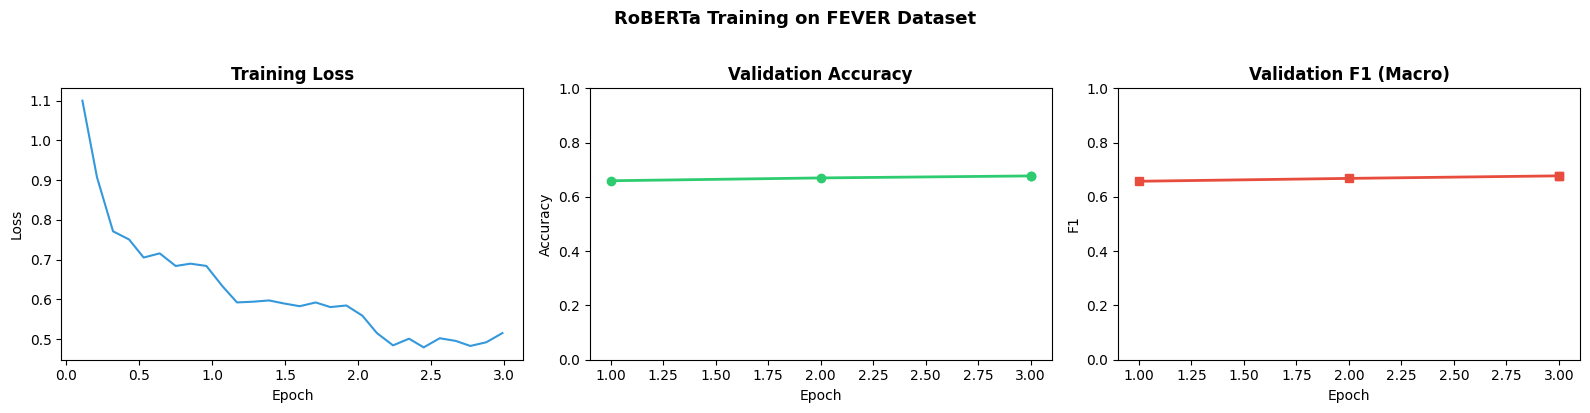

In [ ]:
# Training curves
log_history = trainer.state.log_history
t_losses = [(e["epoch"], e["loss"]) for e in log_history if "loss" in e and "eval_loss" not in e]
e_metrics = [(e["epoch"], e["eval_loss"], e.get("eval_accuracy",0), e.get("eval_f1_macro",0))
             for e in log_history if "eval_loss" in e]

if e_metrics:
    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    if t_losses:
        axes[0].plot([x[0] for x in t_losses],[x[1] for x in t_losses], color="#3498db", lw=1.5)
        axes[0].set_title("Training Loss", fontweight="bold")
        axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[1].plot([x[0] for x in e_metrics],[x[2] for x in e_metrics],
                 color="#2ecc71", marker="o", lw=2)
    axes[1].set_title("Validation Accuracy", fontweight="bold")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy"); axes[1].set_ylim(0,1)
    axes[2].plot([x[0] for x in e_metrics],[x[3] for x in e_metrics],
                 color="#e74c3c", marker="s", lw=2)
    axes[2].set_title("Validation F1 (Macro)", fontweight="bold")
    axes[2].set_xlabel("Epoch"); axes[2].set_ylabel("F1"); axes[2].set_ylim(0,1)
    plt.suptitle("RoBERTa Training on FEVER Dataset", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
    plt.show()


## ⚙️ Step 8 — Rule-Based Verification Engine

Combines two verification layers:

**Layer 1 — KB Lookup:**
- Exact forward & reverse predicate matching
- Conflict detection (same relation, different object → contradiction)

**Layer 2 — Logical Constraint Rules:**
- `capital_of` — a country can have only one capital
- `born_in` — a person can have only one birthplace
- Cross-claim internal consistency checks


In [ ]:
# Load fine-tuned model for inference
try:
    inf_model  = AutoModelForSequenceClassification.from_pretrained(SAVED_MODEL_PATH)
    inf_tok    = AutoTokenizer.from_pretrained(SAVED_MODEL_PATH)
    inf_model.to(DEVICE).eval()
    print(f"✅ Fine-tuned model loaded from {SAVED_MODEL_PATH}")
except Exception as e:
    print(f"⚠️  Using base model ({e})")
    inf_model, inf_tok = model, tokenizer
    inf_model.eval()

def ml_verify(claim: str, evidence: str = "") -> dict:
    enc = inf_tok(claim, evidence, max_length=MAX_LEN, padding="max_length",
                  truncation=True, return_tensors="pt")
    with torch.no_grad():
        logits = inf_model(input_ids=enc["input_ids"].to(DEVICE),
                           attention_mask=enc["attention_mask"].to(DEVICE)).logits
    probs  = torch.softmax(logits, dim=-1).cpu().numpy()[0]
    pid    = int(np.argmax(probs))
    return {"prediction": ID2LABEL[pid], "confidence": float(probs[pid]),
            "probabilities": {ID2LABEL[i]: float(p) for i, p in enumerate(probs)}}

UNIQUE_REL_RULES = {
    "capital_of":  "A country can have only one capital city",
    "born_in":     "A person can have only one place of birth",
    "directed_by": "A film typically has one director (per context)",
}

def kb_verify(pred_info: dict) -> str:
    fwd, rev = pred_info["kb_key_fwd"], pred_info["kb_key_rev"]
    if fwd in json_kb and json_kb[fwd]["verified"]: return "verified"
    if rev in json_kb and json_kb[rev]["verified"]: return "verified"

    rel, subj, obj = pred_info["relation"], pred_info["subject"], pred_info["object"]
    for v in json_kb.values():
        if v.get("relation")==rel and v.get("subject")==subj and v.get("object")!=obj and v["verified"]:
            return "contradiction"
    return "unknown"

def check_internal(predicates: list) -> list:
    violations, groups = [], defaultdict(list)
    for p in predicates:
        groups[p["relation"]].append(p)
    for rel, preds in groups.items():
        if rel in UNIQUE_REL_RULES:
            subj_objs = defaultdict(set)
            for p in preds:
                subj_objs[p["subject"]].add(p["object"])
            for subj, objs in subj_objs.items():
                if len(objs) > 1:
                    violations.append({"type":"internal_contradiction","relation":rel,
                                       "subject":subj,"objects":list(objs),
                                       "rule":UNIQUE_REL_RULES[rel]})
    return violations


test_preds = [
    {"predicate":"capital_of(france,paris)",  "relation":"capital_of","subject":"france",
     "object":"paris", "kb_key_fwd":"capital_of(france,paris)","kb_key_rev":"capital_of(paris,france)"},
    {"predicate":"capital_of(france,berlin)", "relation":"capital_of","subject":"france",
     "object":"berlin","kb_key_fwd":"capital_of(france,berlin)","kb_key_rev":"capital_of(berlin,france)"},
    {"predicate":"born_in(einstein,germany)", "relation":"born_in","subject":"einstein",
     "object":"germany","kb_key_fwd":"born_in(einstein,germany)","kb_key_rev":"born_in(germany,einstein)"},
]
print("Rule Engine Test:")
for p in test_preds:
    kb_res = kb_verify(p)
    ml_res = ml_verify(p["original"]["sentence"] if "original" in p else p["predicate"])
    icon   = {"verified":"✅","contradiction":"❌","unknown":"❓"}[kb_res]
    print(f"  {icon} {p['predicate']!r:40s} → {kb_res} (KB) | ML: {ml_res['prediction']}")


✅ Fine-tuned model loaded from ./fever_roberta_final
Rule Engine Test:
  ✅ 'capital_of(france,paris)'               → verified (KB) | ML: SUPPORTS
  ❌ 'capital_of(france,berlin)'              → contradiction (KB) | ML: SUPPORTS
  ✅ 'born_in(einstein,germany)'              → verified (KB) | ML: SUPPORTS


## 📊 Step 9 — Reliability Scoring Module

**Scoring Formula:**

$$\text{Score} = \text{clip}\left(\frac{V - 0.8 \cdot C - 0.1 \cdot U}{T},\; 0,\; 1\right)$$

| Symbol | Meaning |
|--------|---------|
| $V$ | Verified claims |
| $C$ | Contradicted claims (heavy penalty: 0.8) |
| $U$ | Unknown/unverifiable claims (light penalty: 0.1) |
| $T$ | Total extracted claims |

**Score interpretation:**

| Score | Label |
|-------|-------|
| 0.85–1.00 | 🟢 Highly Reliable |
| 0.65–0.84 | 🟡 Mostly Reliable |
| 0.40–0.64 | 🟠 Partially Reliable |
| 0.00–0.39 | 🔴 Unreliable |


In [ ]:
W_CONTRADICTION = 0.8
W_UNKNOWN       = 0.1
THRESHOLDS      = [(0.85,"Highly Reliable","🟢"),(0.65,"Mostly Reliable","🟡"),
                   (0.40,"Partially Reliable","🟠"),(0.00,"Unreliable","🔴")]

def get_label(score):
    for t, l, i in THRESHOLDS:
        if score >= t: return l, i
    return "Unreliable","🔴"

def analyse_text(text: str) -> dict:
    # 1. Extract triples
    raw_triples = extractor.extract(text)
    if not raw_triples:
        return {"reliability_score":0.5,"label":"Partially Reliable","icon":"🟠",
                "message":"No verifiable claims found","total_claims":0,
                "verified":[],"contradictions":[],"unknown":[],"internal_contradictions":[]}

    # 2. Convert to predicates
    predicates = [to_predicate(t) for t in raw_triples]

    # 3. Check internal constraints
    internal_c = check_internal(predicates)

    # 4. Verify each predicate
    verified, contradictions, unknown_claims = [], [], []
    for pred in predicates:
        kb_res = kb_verify(pred)
        ml_res = ml_verify(pred["original"].get("sentence", text))
        if kb_res == "verified":
            status, source = "verified", "knowledge_base"
        elif kb_res == "contradiction":
            status, source = "contradiction", "knowledge_base"
        elif ml_res["prediction"] == "SUPPORTS":
            status, source = "verified", "ml_model"
        elif ml_res["prediction"] == "REFUTES":
            status, source = "contradiction", "ml_model"
        else:
            status, source = "unknown", "unverified"
        entry = {"predicate":pred["predicate"],"status":status,"source":source,"ml":ml_res}
        (verified if status=="verified" else
         contradictions if status=="contradiction" else unknown_claims).append(entry)

    # 5. Compute score
    V = len(verified)
    C = len(contradictions) + len(internal_c)
    U = len(unknown_claims)
    T = len(predicates)
    raw   = (V - W_CONTRADICTION*C - W_UNKNOWN*U) / max(T, 1)
    score = round(max(0.0, min(1.0, raw)), 4)
    label, icon = get_label(score)

    return {
        "reliability_score": score, "label": label, "icon": icon,
        "total_claims": T, "verified_count": V,
        "contradiction_count": C, "unknown_count": U,
        "verified": verified, "contradictions": contradictions,
        "unknown": unknown_claims, "internal_contradictions": internal_c,
        "formula": {"V":V,"C":C,"U":U,"T":T,"w_c":W_CONTRADICTION,"w_u":W_UNKNOWN},
    }

# Full pipeline demo
TEST_CASES = [
    ("✅ Correct text",
     "Paris is the capital of France. Albert Einstein was born in Germany. "
     "The Eiffel Tower is located in Paris."),
    ("❌ Hallucinated text",
     "Paris is the capital of Germany. Einstein was born in Australia. "
     "The Amazon river flows through Europe."),
    ("⚠️  Mixed reliability",
     "London is the capital of the UK. Shakespeare wrote Hamlet. "
     "The Great Wall of China is located in Japan."),
    ("❓ Unverifiable claims",
     "The Xenon Particle Matrix was invented by Dr. Volkov in 1944. "
     "The Trilobyte Corporation founded the quantum resonance project."),
]

print("=" * 70)
for name, text in TEST_CASES:
    r = analyse_text(text)
    print(f"\n{name}")
    print(f"  Text: {text[:75]}...")
    print(f"  {r['icon']} Score: {r['reliability_score']:.4f}  →  {r['label']}")
    print(f"  Total:{r['total_claims']}  ✅Verified:{r['verified_count']}  "
          f"❌Contradicted:{r['contradiction_count']}  ❓Unknown:{r['unknown_count']}")
    if r["contradictions"]:
        for c in r["contradictions"][:2]:
            print(f"    ❌ {c['predicate']}  (via {c['source']})")
print("=" * 70)



✅ Correct text
  Text: Paris is the capital of France. Albert Einstein was born in Germany. The Ei...
  🟠 Score: 0.6333  →  Partially Reliable
  Total:3  ✅Verified:2  ❌Contradicted:0  ❓Unknown:1

❌ Hallucinated text
  Text: Paris is the capital of Germany. Einstein was born in Australia. The Amazon...
  🔴 Score: 0.0000  →  Unreliable
  Total:2  ✅Verified:0  ❌Contradicted:2  ❓Unknown:0
    ❌ capital_of(germany,paris)  (via knowledge_base)
    ❌ born_in(einstein,australia)  (via knowledge_base)

⚠️  Mixed reliability
  Text: London is the capital of the UK. Shakespeare wrote Hamlet. The Great Wall o...
  🟠 Score: 0.5500  →  Partially Reliable
  Total:4  ✅Verified:3  ❌Contradicted:1  ❓Unknown:0
    ❌ located_in(great_wall_of_china,japan)  (via ml_model)

❓ Unverifiable claims
  Text: The Xenon Particle Matrix was invented by Dr. Volkov in 1944. The Trilobyte...
  🟠 Score: 0.4500  →  Partially Reliable
  Total:2  ✅Verified:1  ❌Contradicted:0  ❓Unknown:1


## 📈 Step 10 — Model Evaluation & Confusion Matrix

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score

print("Running inference on validation set (first 4,000 samples)...")
BATCH = 64
all_preds, all_labels = [], []

for i in tqdm(range(0, min(len(processed_val), 4000), BATCH), desc="Eval"):
    batch = processed_val[i:i+BATCH]
    claims    = [ex["claim"]    for ex in batch]
    evidences = [ex["evidence"] if ex.get("evidence") else "" for ex in batch]
    labels    = [ex["label"]    for ex in batch]
    enc = inf_tok(claims, evidences, max_length=MAX_LEN,
                  padding="max_length", truncation=True, return_tensors="pt")
    with torch.no_grad():
        logits = inf_model(input_ids=enc["input_ids"].to(DEVICE),
                           attention_mask=enc["attention_mask"].to(DEVICE)).logits
    all_preds.extend(torch.argmax(logits, dim=-1).cpu().numpy().tolist())
    all_labels.extend(labels)

label_names = [ID2LABEL[i] for i in range(3)]
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=label_names, digits=4))
print(f"Overall Accuracy:  {accuracy_score(all_labels, all_preds):.4f}")
print(f"Macro F1 Score:    {f1_score(all_labels, all_preds, average='macro'):.4f}")


Running inference on validation set (first 4,000 samples)...


Eval:   0%|          | 0/63 [00:00<?, ?it/s]


Classification Report:
                 precision    recall  f1-score   support

       SUPPORTS     0.7426    0.6757    0.7076      1699
        REFUTES     0.7460    0.7603    0.7531      1402
NOT ENOUGH INFO     0.5241    0.5951    0.5573       931

       accuracy                         0.6865      4032
      macro avg     0.6709    0.6770    0.6727      4032
   weighted avg     0.6933    0.6865    0.6887      4032

Overall Accuracy:  0.6865
Macro F1 Score:    0.6727


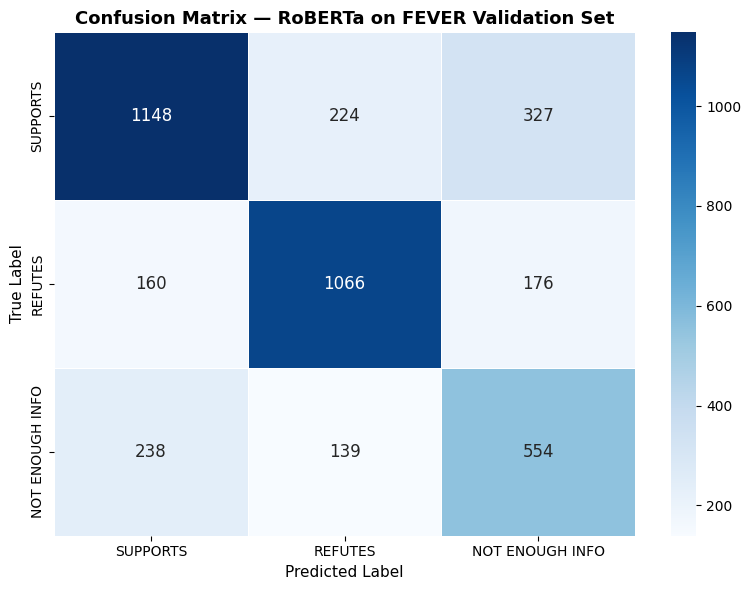

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=label_names, yticklabels=label_names,
            linewidths=0.5, annot_kws={"size":12}, ax=ax)
ax.set_title("Confusion Matrix — RoBERTa on FEVER Validation Set",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Predicted Label", fontsize=11)
ax.set_ylabel("True Label", fontsize=11)
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=120, bbox_inches="tight")
plt.show()


In [ ]:
# Downloading the model + knowledge base to computer
from google.colab import files
import shutil, os

# Zip the model folder
shutil.make_archive("fever_roberta_final", "zip", ".", "fever_roberta_final")

# Downloading both files
files.download("fever_roberta_final.zip")
files.download("knowledge_base.json")

print("✅ Download both files, then unzip fever_roberta_final.zip")
print("   Place them in the same folder as app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Download both files, then unzip fever_roberta_final.zip
   Place them in the same folder as app.py


## 🚀 Step 11 — FastAPI Backend

In [ ]:
APP_CODE = '''
import json, re, warnings
from pathlib import Path
from typing import Optional
from collections import defaultdict

import numpy as np
import torch
import spacy
from fastapi import FastAPI, HTTPException
from fastapi.responses import HTMLResponse
from fastapi.middleware.cors import CORSMiddleware
from pydantic import BaseModel, Field
from transformers import AutoTokenizer, AutoModelForSequenceClassification

warnings.filterwarnings("ignore")

SAVED_MODEL_PATH = "./fever_roberta_final"
KB_PATH          = "knowledge_base.json"
DEVICE   = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ID2LABEL = {0:"SUPPORTS", 1:"REFUTES", 2:"NOT ENOUGH INFO"}
LABEL2ID = {v:k for k,v in ID2LABEL.items()}
MAX_LEN  = 256
W_C, W_U = 0.8, 0.1
THRESHOLDS = [
    (0.85, "Highly Reliable",    "green"),
    (0.65, "Mostly Reliable",    "yellow"),
    (0.40, "Partially Reliable", "orange"),
    (0.00, "Unreliable",         "red"),
]

print("Loading spaCy...")
nlp = spacy.load("en_core_web_sm")

print("Loading knowledge base...")
with open(KB_PATH) as f:
    json_kb = json.load(f)

print("Loading ML model...")
try:
    tok = AutoTokenizer.from_pretrained(SAVED_MODEL_PATH)
    mdl = AutoModelForSequenceClassification.from_pretrained(SAVED_MODEL_PATH)
    mdl.to(DEVICE).eval()
    print(f"Model loaded on {DEVICE}")
except Exception as e:
    print(f"Falling back to base roberta: {e}")
    tok = AutoTokenizer.from_pretrained("roberta-base")
    mdl = AutoModelForSequenceClassification.from_pretrained(
        "roberta-base", num_labels=3, id2label=ID2LABEL, label2id=LABEL2ID)
    mdl.to(DEVICE).eval()

ENTITY_ALIASES = {
    "usa":"united_states","us":"united_states","uk":"united_kingdom",
    "britain":"united_kingdom","america":"united_states",
}
REL_NORM = {
    "be":"is_a","create":"created_by","invent":"created_by",
    "write":"created_by","locate":"located_in","bear":"born_in",
}
REL_PATS = [
    (r"(.+?) is the capital of (.+)",             "capital_of"),
    (r"(.+?) is (?:located|situated) in (.+)",    "located_in"),
    (r"(.+?) was born in (.+)",                   "born_in"),
    (r"(.+?) was (?:created|invented) by (.+)",   "created_by"),
    (r"(.+?) is an? (.+)",                        "is_a"),
    (r"(.+?) wrote (.+)",                         "created_by"),
]
UNIQUE_RELS = {"capital_of", "born_in"}

def norm(t):
    return re.sub(r"[\\x00-\\x1f\\x7f]", "", re.sub(r"\\s+", " ", t.strip()))

def canon(t):
    t = re.sub(r"\\b(the|a|an)\\b\\s*", "", t.lower().strip())
    t = re.sub(r"[^a-z0-9\\s]", "", t)
    t = re.sub(r"\\s+", "_", t.strip())
    return ENTITY_ALIASES.get(t, t)

def extract_triples(text):
    triples, seen = [], set()
    doc = nlp(norm(text))
    for sent in doc.sents:
        s = sent.text.lower()
        for pat, rel in REL_PATS:
            m = re.search(pat, s)
            if m:
                gg = m.groups()
                sb = gg[1].strip() if rel == "capital_of" else gg[0].strip()
                ob = gg[0].strip() if rel == "capital_of" else gg[-1].strip()
                if 2 <= len(sb) <= 80 and 2 <= len(ob) <= 80:
                    k = (sb, rel, ob)
                    if k not in seen:
                        seen.add(k)
                        triples.append({"subject":sb,"relation":rel,
                                        "object":ob,"sentence":sent.text})
    return triples

def to_pred(t):
    s = canon(t["subject"]); o = canon(t["object"])
    r = REL_NORM.get(t["relation"].lower(), t["relation"].lower())
    r = re.sub(r"[^a-z0-9_]", "_", r)
    return {"predicate":f"{r}({s},{o})","relation":r,"subject":s,"object":o,
            "original":t,"kb_key_fwd":f"{r}({s},{o})","kb_key_rev":f"{r}({o},{s})"}

def kb_check(p):
    if p["kb_key_fwd"] in json_kb and json_kb[p["kb_key_fwd"]]["verified"]:
        return "verified"
    if p["kb_key_rev"] in json_kb and json_kb[p["kb_key_rev"]]["verified"]:
        return "verified"
    for v in json_kb.values():
        if (v.get("relation") == p["relation"] and
            v.get("subject")  == p["subject"]  and
            v.get("object")   != p["object"]   and v["verified"]):
            return "contradiction"
    return "unknown"

def ml_check(claim, ev=""):
    enc = tok(claim, ev, max_length=MAX_LEN, padding="max_length",
              truncation=True, return_tensors="pt")
    with torch.no_grad():
        lg = mdl(input_ids=enc["input_ids"].to(DEVICE),
                 attention_mask=enc["attention_mask"].to(DEVICE)).logits
    probs = torch.softmax(lg, dim=-1).cpu().numpy()[0]
    pid   = int(np.argmax(probs))
    return {"prediction":ID2LABEL[pid], "confidence":float(probs[pid]),
            "probabilities":{ID2LABEL[i]:float(p) for i,p in enumerate(probs)}}

def check_internal(preds):
    viol, groups = [], defaultdict(list)
    for p in preds:
        groups[p["relation"]].append(p)
    for rel, ps in groups.items():
        if rel in UNIQUE_RELS:
            so = defaultdict(set)
            for p in ps: so[p["subject"]].add(p["object"])
            for s, os in so.items():
                if len(os) > 1:
                    viol.append({"type":"internal_contradiction",
                                 "relation":rel,"subject":s,"objects":list(os)})
    return viol

def get_label(score):
    for t, l, c in THRESHOLDS:
        if score >= t: return l, c
    return "Unreliable", "red"

def run_pipeline(text):
    raw = extract_triples(text)
    if not raw:
        return {"reliability_score":0.5,"label":"Partially Reliable","color":"orange",
                "message":"No verifiable claims found","total_claims":0,
                "verified":[],"contradictions":[],"unknown":[],"internal_contradictions":[]}
    preds = [to_pred(t) for t in raw]
    ic    = check_internal(preds)
    verified, contradictions, unknown = [], [], []
    for p in preds:
        kb = kb_check(p)
        ml = ml_check(p["original"].get("sentence", text))
        if   kb == "verified":      st, src = "verified",      "knowledge_base"
        elif kb == "contradiction":  st, src = "contradiction",  "knowledge_base"
        elif ml["prediction"] == "SUPPORTS": st, src = "verified",      "ml_model"
        elif ml["prediction"] == "REFUTES":  st, src = "contradiction",  "ml_model"
        else:                        st, src = "unknown",        "unverified"
        e = {"predicate":p["predicate"],"status":st,"source":src,"ml":ml}
        (verified if st=="verified" else
         contradictions if st=="contradiction" else unknown).append(e)
    V=len(verified); C=len(contradictions)+len(ic); U=len(unknown); T=len(preds)
    score = round(max(0.0, min(1.0, (V - W_C*C - W_U*U) / max(T,1))), 4)
    label, color = get_label(score)
    return {"reliability_score":score,"label":label,"color":color,
            "total_claims":T,"verified_count":V,"contradiction_count":C,"unknown_count":U,
            "verified":verified,"contradictions":contradictions,"unknown":unknown,
            "internal_contradictions":ic}

# ── HTML page (served at GET /) ──────────────────────────────────────────────
HTML_PAGE = """
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width,initial-scale=1">
<title>LLM Reliability Engine</title>
<style>
*{margin:0;padding:0;box-sizing:border-box}
body{font-family:-apple-system,BlinkMacSystemFont,\'Segoe UI\',sans-serif;
  background:#f4f5f7;color:#1a1d23;min-height:100vh;font-size:15px}
header{background:#fff;border-bottom:1px solid #e2e5ea;padding:16px 24px;
  display:flex;align-items:center;gap:12px;position:sticky;top:0;z-index:10}
.logo{width:36px;height:36px;background:#4f46e5;border-radius:8px;display:flex;
  align-items:center;justify-content:center;font-size:18px}
header h1{font-size:16px;font-weight:600}
header p{font-size:12px;color:#6b7280;margin-top:1px}
.badge{margin-left:auto;background:#eef2ff;color:#4f46e5;font-size:11px;
  font-weight:600;padding:3px 10px;border-radius:20px;border:1px solid #c7d2fe}
.container{max-width:860px;margin:0 auto;padding:28px 20px;display:flex;
  flex-direction:column;gap:20px}
.card{background:#fff;border:1px solid #e2e5ea;border-radius:12px;overflow:hidden}
.card-head{padding:14px 18px;border-bottom:1px solid #e2e5ea;
  display:flex;align-items:center;gap:10px}
.card-head h2{font-size:13px;font-weight:600;letter-spacing:.01em}
.num{width:22px;height:22px;background:#4f46e5;color:#fff;border-radius:50%;
  font-size:11px;font-weight:700;display:flex;align-items:center;justify-content:center}
.card-body{padding:18px}
textarea{width:100%;font-family:inherit;font-size:14px;padding:12px 14px;
  border:1px solid #dde0e6;border-radius:8px;resize:vertical;min-height:140px;
  background:#fafafa;outline:none;transition:border .2s,background .2s;line-height:1.6}
textarea:focus{border-color:#4f46e5;background:#fff;
  box-shadow:0 0 0 3px rgba(79,70,229,.08)}
.row{display:flex;gap:10px;margin-top:12px;align-items:center}
.hint{font-size:12px;color:#9ca3af}
button{font-family:inherit;font-size:14px;font-weight:500;padding:10px 22px;
  background:#4f46e5;color:#fff;border:none;border-radius:8px;cursor:pointer;
  transition:background .15s,transform .1s;white-space:nowrap}
button:hover{background:#4338ca}
button:active{transform:scale(.98)}
button:disabled{background:#9ca3af;cursor:not-allowed}
.clear-btn{background:none;color:#6b7280;border:1px solid #dde0e6;padding:10px 16px;
  font-size:13px}
.clear-btn:hover{background:#f4f5f7}

/* score card */
.score-card{padding:22px 18px;display:flex;align-items:center;gap:18px;
  border-bottom:1px solid #e2e5ea}
.score-ring{position:relative;width:76px;height:76px;flex-shrink:0}
.score-ring svg{transform:rotate(-90deg)}
.score-ring .track{fill:none;stroke:#f0f1f3;stroke-width:7}
.score-ring .fill{fill:none;stroke-width:7;stroke-linecap:round;
  transition:stroke-dashoffset .8s ease,stroke .4s}
.score-num{position:absolute;inset:0;display:flex;align-items:center;
  justify-content:center;font-size:17px;font-weight:700}
.score-info h3{font-size:22px;font-weight:700;line-height:1.2}
.score-info p{font-size:13px;color:#6b7280;margin-top:3px}
.pill{display:inline-block;font-size:12px;font-weight:600;padding:3px 11px;
  border-radius:20px;margin-top:8px}

/* stats grid */
.stats{display:grid;grid-template-columns:repeat(3,1fr);gap:10px;padding:16px 18px;
  border-bottom:1px solid #e2e5ea}
.stat{background:#f8f9fb;border-radius:8px;padding:12px 14px;text-align:center}
.stat-num{font-size:22px;font-weight:700}
.stat-lbl{font-size:11px;color:#6b7280;margin-top:2px;font-weight:500}

/* claims lists */
.claims-wrap{padding:16px 18px}
.section-title{font-size:12px;font-weight:600;color:#6b7280;letter-spacing:.05em;
  text-transform:uppercase;margin-bottom:10px;margin-top:14px}
.section-title:first-child{margin-top:0}
.claim-item{display:flex;gap:10px;align-items:flex-start;padding:9px 12px;
  border-radius:8px;margin-bottom:6px;font-size:13px;line-height:1.5}
.claim-icon{font-size:15px;margin-top:1px;flex-shrink:0}
.claim-pred{font-family:\'Courier New\',monospace;font-size:12px;font-weight:600;
  word-break:break-all}
.claim-src{font-size:11px;margin-top:2px;opacity:.7}
.v-item{background:#f0fdf4;border:1px solid #bbf7d0}
.c-item{background:#fef2f2;border:1px solid #fecaca}
.u-item{background:#f9fafb;border:1px solid #e5e7eb}
.empty{text-align:center;padding:32px;color:#9ca3af;font-size:13px}

/* loading */
.loading{display:none;align-items:center;gap:10px;color:#6b7280;font-size:14px}
.spinner{width:18px;height:18px;border:2px solid #e2e5ea;border-top-color:#4f46e5;
  border-radius:50%;animation:spin .7s linear infinite}
@keyframes spin{to{transform:rotate(360deg)}}

/* error */
.error-box{background:#fef2f2;border:1px solid #fecaca;border-radius:8px;
  padding:12px 14px;font-size:13px;color:#dc2626;display:none}

/* color helpers */
.green{color:#16a34a} .red{color:#dc2626} .yellow{color:#d97706} .orange{color:#ea580c}
.pill-green{background:#f0fdf4;color:#15803d;border:1px solid #bbf7d0}
.pill-yellow{background:#fffbeb;color:#b45309;border:1px solid #fde68a}
.pill-orange{background:#fff7ed;color:#c2410c;border:1px solid #fed7aa}
.pill-red{background:#fef2f2;color:#b91c1c;border:1px solid #fecaca}
#result-card{display:none}
</style>
</head>
<body>

<header>
  <div class="logo">🧠</div>
  <div>
    <h1>Neuro-Symbolic LLM Reliability Engine</h1>
    <p>Fact verification using RoBERTa + Symbolic Reasoning</p>
  </div>
  <span class="badge">localhost:8000</span>
</header>

<div class="container">

  <!-- Input card -->
  <div class="card">
    <div class="card-head">
      <div class="num">1</div>
      <h2>Paste LLM-Generated Text</h2>
    </div>
    <div class="card-body">
      <textarea id="input-text"
        placeholder="Paste any LLM-generated paragraph here and click Analyse...

Example: Paris is the capital of Germany. Albert Einstein was born in Australia. The Eiffel Tower is located in Paris."></textarea>
      <div class="row">
        <button id="analyse-btn" onclick="analyse()">Analyse Text</button>
        <button class="clear-btn" onclick="clearAll()">Clear</button>
        <div class="loading" id="loading">
          <div class="spinner"></div>
          <span>Analysing claims...</span>
        </div>
      </div>
      <div class="error-box" id="error-box"></div>
    </div>
  </div>

  <!-- Result card -->
  <div class="card" id="result-card">
    <div class="card-head">
      <div class="num">2</div>
      <h2>Reliability Report</h2>
    </div>

    <!-- Score -->
    <div class="score-card">
      <div class="score-ring">
        <svg width="76" height="76" viewBox="0 0 76 76">
          <circle class="track" cx="38" cy="38" r="32"/>
          <circle class="fill" id="score-arc" cx="38" cy="38" r="32"
            stroke-dasharray="201" stroke-dashoffset="201"/>
        </svg>
        <div class="score-num" id="score-num">0</div>
      </div>
      <div class="score-info">
        <h3 id="score-pct">0%</h3>
        <p>Reliability score</p>
        <span class="pill" id="score-pill">—</span>
      </div>
    </div>

    <!-- Stats -->
    <div class="stats">
      <div class="stat">
        <div class="stat-num" id="s-total">0</div>
        <div class="stat-lbl">Total Claims</div>
      </div>
      <div class="stat">
        <div class="stat-num green" id="s-verified">0</div>
        <div class="stat-lbl">Verified</div>
      </div>
      <div class="stat">
        <div class="stat-num red" id="s-contra">0</div>
        <div class="stat-lbl">Contradicted</div>
      </div>
    </div>

    <!-- Claims breakdown -->
    <div class="claims-wrap" id="claims-wrap"></div>
  </div>

</div>

<script>
const API = "http://localhost:8000";

async function analyse() {
  const text = document.getElementById("input-text").value.trim();
  if (!text) return;

  setLoading(true);
  hideError();
  document.getElementById("result-card").style.display = "none";

  try {
    const res  = await fetch(API + "/analyse", {
      method: "POST",
      headers: {"Content-Type":"application/json"},
      body: JSON.stringify({text})
    });
    if (!res.ok) throw new Error("Server error: " + res.status);
    const data = await res.json();
    renderResult(data);
  } catch(e) {
    showError("Could not connect to backend. Make sure app.py is running on localhost:8000.<br><code>" + e.message + "</code>");
  } finally {
    setLoading(false);
  }
}

function renderResult(d) {
  const score   = d.reliability_score;
  const color   = d.color;
  const colorMap = {
    green:"#16a34a", yellow:"#d97706", orange:"#ea580c", red:"#dc2626"
  };
  const hex = colorMap[color] || "#6b7280";

  // Ring
  const circ   = 2 * Math.PI * 32;
  const offset = circ * (1 - score);
  const arc    = document.getElementById("score-arc");
  arc.style.stroke          = hex;
  arc.style.strokeDashoffset = offset;

  document.getElementById("score-num").textContent  = Math.round(score * 100);
  document.getElementById("score-pct").textContent  = Math.round(score * 100) + "%";
  document.getElementById("score-pct").style.color  = hex;

  const pill = document.getElementById("score-pill");
  pill.textContent  = d.label;
  pill.className    = "pill pill-" + color;

  document.getElementById("s-total").textContent    = d.total_claims;
  document.getElementById("s-verified").textContent = d.verified_count;
  document.getElementById("s-contra").textContent   = d.contradiction_count;

  // Claims breakdown
  const wrap = document.getElementById("claims-wrap");
  wrap.innerHTML = "";

  const sections = [
    {key:"verified",      title:"✅  Verified claims",      cls:"v-item", icon:"✅"},
    {key:"contradictions",title:"❌  Contradicted claims",  cls:"c-item", icon:"❌"},
    {key:"unknown",       title:"❓  Unverifiable claims",  cls:"u-item", icon:"❓"},
  ];

  sections.forEach(({key, title, cls, icon}) => {
    const items = d[key];
    if (!items || items.length === 0) return;
    const h = document.createElement("div");
    h.className = "section-title"; h.textContent = title;
    wrap.appendChild(h);
    items.forEach(item => {
      const div = document.createElement("div");
      div.className = "claim-item " + cls;
      div.innerHTML =
        `<span class="claim-icon">${icon}</span>` +
        `<div><div class="claim-pred">${item.predicate}</div>` +
        `<div class="claim-src">source: ${item.source}` +
        (item.ml ? `  ·  model: ${item.ml.prediction} (${(item.ml.confidence*100).toFixed(1)}%)` : "") +
        `</div></div>`;
      wrap.appendChild(div);
    });
  });

  if (d.total_claims === 0) {
    wrap.innerHTML = `<div class="empty">No verifiable claims were extracted from this text.</div>`;
  }

  document.getElementById("result-card").style.display = "block";
  document.getElementById("result-card").scrollIntoView({behavior:"smooth",block:"start"});
}

function setLoading(on) {
  document.getElementById("loading").style.display     = on ? "flex" : "none";
  document.getElementById("analyse-btn").disabled = on;
}
function showError(msg) {
  const b = document.getElementById("error-box");
  b.innerHTML = msg; b.style.display = "block";
}
function hideError() {
  document.getElementById("error-box").style.display = "none";
}
function clearAll() {
  document.getElementById("input-text").value = "";
  document.getElementById("result-card").style.display = "none";
  hideError();
}

document.getElementById("input-text").addEventListener("keydown", e => {
  if (e.ctrlKey && e.key === "Enter") analyse();
});
</script>
</body>
</html>
"""

# ── FastAPI app ────────────────────────────────────────────────────────────────
app = FastAPI(title="Neuro-Symbolic LLM Reliability Engine", version="1.0.0")
app.add_middleware(CORSMiddleware, allow_origins=["*"],
                   allow_methods=["*"], allow_headers=["*"])

class AnalyseRequest(BaseModel):
    text: str = Field(..., min_length=5)
    evidence: Optional[str] = None

@app.get("/", response_class=HTMLResponse)
def serve_ui():
    return HTML_PAGE

@app.get("/health")
def health():
    return {"status":"ok","device":str(DEVICE),"kb_size":len(json_kb)}

@app.post("/analyse")
def analyse(req: AnalyseRequest):
    if len(req.text.strip()) < 5:
        raise HTTPException(400, "Text too short")
    result = run_pipeline(req.text)
    result["input_text"] = req.text[:500]
    return result

@app.get("/kb/stats")
def kb_stats():
    from collections import Counter
    rels = Counter(v.get("relation","?") for v in json_kb.values())
    return {"total_entries":len(json_kb),"top_relations":dict(rels.most_common(10))}
'''

with open("app.py", "w") as f:
    f.write(APP_CODE)
print("✅ app.py written")
print("Next: download your model + KB using the cell above, then follow the steps below.")